<a href="https://colab.research.google.com/github/artur-asm/Sinais-e-Sistemas-em-Tempo-Discreto/blob/main/Projeto_3_DTMF/projeto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [ ]:
#Código das funções utilizadas.

def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X


def idft(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(1j * 2 * np.pi * k * n / N)
    x = x / N
    return x


def filtra_passa_baixa(x, fc_norm):
    """filtra o sinal x[n] com um filtro passa-baixas ideal.
    transformar pro dominio da frequencia,
    zerar as componentes acima da frequencia de corte,
    e voltar pro dominio do tempo.
    fc_norm: frequencia de corte normalizada (entre 0 e 1, onde 1 = fs/2)
    """
    N = len(x)

    X = dft(x)

    # indice correspondente a frequencia de corte
    # fc_norm vai de 0 a 1 (1 = metade da taxa de amostragem)
    # no vetor da dft, o indice N/2 corresponde a frequencia de nyquist
    k_corte = int(fc_norm * N / 2)

    # mascara do filtro ideal
    # passa as frequencias de 0 ate k_corte, zera o resto
    # mas precisa manter a simetria conjugada pra garantir sinal real na saida
    H = np.zeros(N)
    H[0:k_corte+1] = 1 # frequencias positivas
    H[N-k_corte:N] = 1 # frequencias negativas

    # filtragem = multiplicacao ponto a ponto no dominio da frequencia
    Y = X * H

    y = idft(Y)

    return np.real(y), H


def plota_sinal(n, x, titulo='sinal', xlabel='n', ylabel='amplitude'):
    """funcao auxiliar pra padronizar os plots."""
    plt.figure(figsize=(10, 3))
    plt.stem(n, x, linefmt='b-', markerfmt='bo', basefmt='k-')
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plota_espectro(X, fs=1, titulo='espectro'):
    """plota magnitude e fase do espectro, centralizado em 0."""
    N = len(X)
    # eixo de frequencias normalizado, centralizado em 0
    freqs = np.arange(N) / N
    # shift pra centralizar: de [0, 1) pra [-0.5, 0.5)
    freqs = freqs - (freqs >= 0.5).astype(int)
    freqs = freqs * fs  # escala pra Hz se quiser

    # ordena pra ficar bonitinho no plot
    idx = np.argsort(freqs)
    freqs = freqs[idx]
    mag = np.abs(X[idx])
    fase = np.angle(X[idx])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

    ax1.plot(freqs, mag, 'b-')
    ax1.set_title(f'{titulo} - magnitude')
    ax1.set_ylabel('|X|')
    ax1.grid(True, alpha=0.3)

    ax2.plot(freqs, fase, 'r-')
    ax2.set_title(f'{titulo} - fase')
    ax2.set_xlabel('frequência (Hz)' if fs != 1 else 'frequência normalizada')
    ax2.set_ylabel('fase (rad)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Questão 1

Considere um sinal $x\left(t\right) = 8 \cdot \text{ret}\left(t\right)$, onde:

$$ \begin{align}
	\text{ret}\left(x\right) = \begin{cases}
                               0 & \text{se} ~~ \left|x\right| > \frac{1}{2} \\
															 \frac{1}{2} & \text{se} ~~ \left|x\right| = \frac{1}{2} \\
															 1 & \text{se} ~~ \left|x\right| < \frac{1}{2} \\
                             \end{cases}
\end{align}                             
$$

Considere que o sinal será amostrado a uma taxa $T = \frac{1}{8}$ s, e que queremos uma resolução na frequência de $f_0 = \frac{1}{4}$ Hz.



## Questão 1a (1.0 ponto)

Obtenha o sinal $x\left[n\right]$, como uma amostragem de $x\left(t\right)$ .

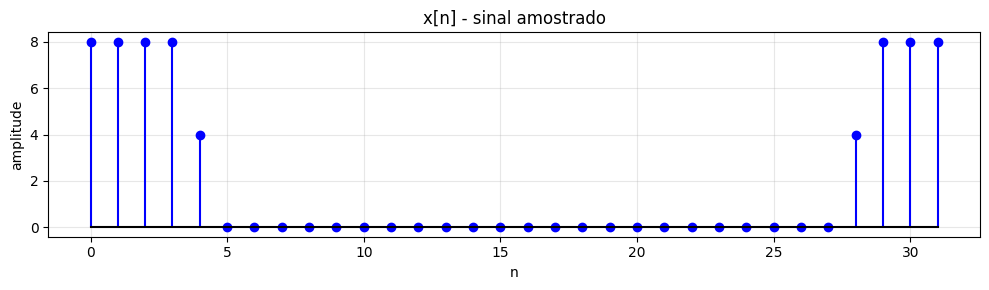

In [ ]:
#Resposta da questão 1a

# parametros
T = 1/8 # periodo de amostragem
fs = 1/T # frequencia de amostragem = 8 Hz
f0 = 1/4 # resolucao desejada na frequencia


# f0 = fs / N  =>  N = fs / f0
N = int(fs / f0)  # N = 8 / 0.25 = 32 amostras

# vetor de indices e instantes de amostragem
n = np.arange(N)
t = n * T

# amostragem de x(t) = 8 * ret(t)
# ret(t) = 1 se |t| < 0.5, 0.5 se |t| = 0.5, 0 se |t| > 0.5
# como t vai de 0 a 31/8 = 3.875, so temos amostras com t >= 0
# entao ret(t) = 1 para t < 0.5 (indices n=0,1,2,3 -> t=0, 0.125, 0.25, 0.375)
# ret(t) = 0.5 para t = 0.5 (indice n=4 -> t=0.5)
# ret(t) = 0 para t > 0.5
# e pra t=0: |t|=0 < 0.5, entao ret(0)=1

x = np.zeros(N)
for i in range(N):
    t_val = t[i]
    if t_val > (N/2 * T):
        t_val -= N * T

    if abs(t_val) < 0.5:
        x[i] = 8 * 1
    elif abs(t_val) == 0.5:
        x[i] = 8 * 0.5
    else:
        x[i] = 0

# plotando x[n]
plt.figure(figsize=(10, 3))
plt.stem(n, x, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('x[n] - sinal amostrado')
plt.xlabel('n')
plt.ylabel('amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Questão 1b (1.0 ponto)

Compare a transformada de Fourier real do sinal $x\left(t\right)$ com a Transformada Discreta de Fourier obtida a partir de $x\left[n\right]$ .

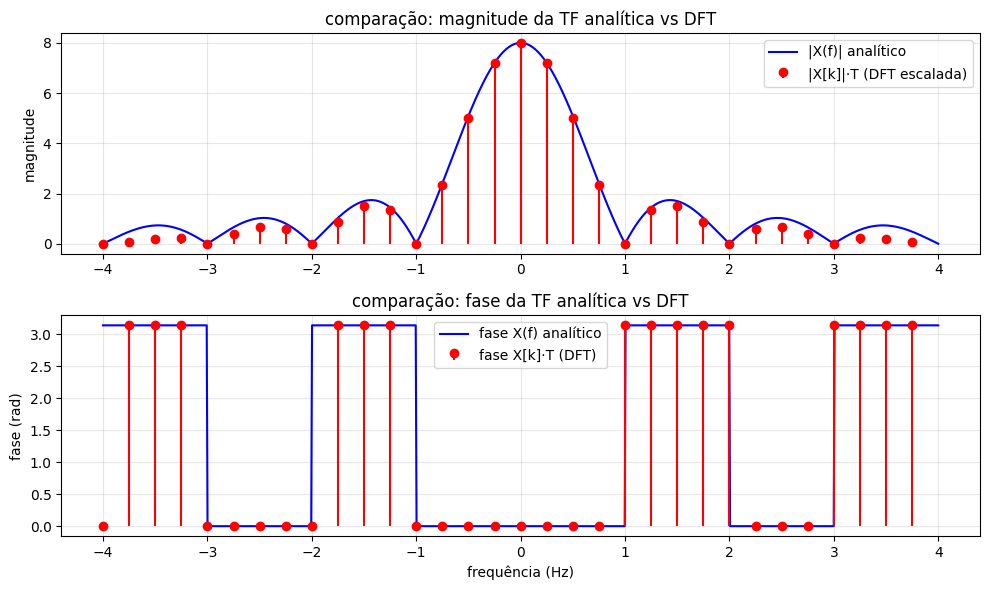

In [ ]:
#Resposta da questão 1b

# x(t) = 8 * ret(t)
# X(f) = 8 * sinc(f)

f_continuo = np.linspace(-fs/2, fs/2, 1000)
X_analitico = 8 * np.sinc(f_continuo)

X_dft = dft(x)

# eixo de frequencias da dft em Hz
# cada bin k corresponde a f = k * f0 = k * (fs/N)
f_dft = np.arange(N) * f0

# shift pra centralizar em torno de 0
f_dft_shift = f_dft.copy()
f_dft_shift[f_dft >= fs/2] -= fs
idx_sort = np.argsort(f_dft_shift)
f_dft_shift = f_dft_shift[idx_sort]

# X[k] = (1/T) * X_c(f)  (a menos de aliasing)
X_dft_escalado = X_dft * T

X_dft_escalado.imag[np.abs(X_dft_escalado.imag) < 1e-10] = 0

# plot da comparacao
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# magnitude
ax1.plot(f_continuo, np.abs(X_analitico), 'b-', label='|X(f)| analítico')
ax1.stem(f_dft_shift, np.abs(X_dft_escalado[idx_sort]),
         linefmt='r-', markerfmt='ro', basefmt=' ',
         label='|X[k]|·T (DFT escalada)')
ax1.set_title('comparação: magnitude da TF analítica vs DFT')
ax1.set_ylabel('magnitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

# fase
ax2.plot(f_continuo, np.angle(X_analitico), 'b-', label='fase X(f) analítico')
ax2.stem(f_dft_shift, np.angle(X_dft_escalado[idx_sort]),
         linefmt='r-', markerfmt='ro', basefmt=' ',
         label='fase X[k]·T (DFT)')
ax2.set_title('comparação: fase da TF analítica vs DFT')
ax2.set_xlabel('frequência (Hz)')
ax2.set_ylabel('fase (rad)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Questão 2

Considere um sinal $x\left[n\right]$ com $N = 256$ amostras, onde:
$$
\begin{align}
	x\left[n\right] = \begin{cases}
                               1 & \text{se} ~~ n < 64 \\
															 0 & \text{se} ~~ n \geq 64 \\
                             \end{cases}
\end{align}
$$

Considere agora um filtro passa-baixas ideal $H_1$ com frequência de corte normalizada igual a $\frac{1}{16}$.

## Questão 2a (1.0  ponto)

Filtre o sinal $x\left[n\right]$ com o filtro $H_1$, obtendo o sinal $y\left[n\right]$. Compare o sinal original $x\left[n\right]$ com o sinal obtido $y\left[n\right]$.

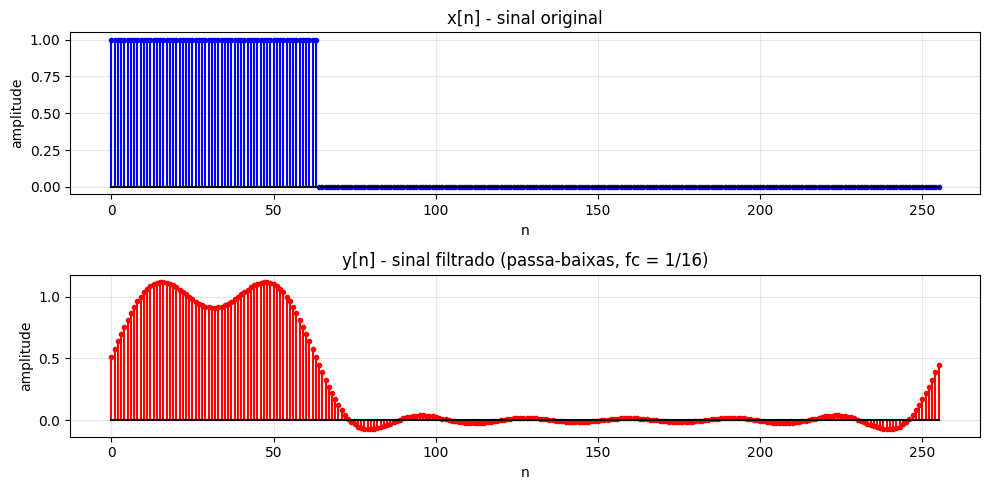

In [ ]:
#Resposta da questão 2a

N2 = 256
n2 = np.arange(N2)

x2 = np.zeros(N2)
x2[n2 < 64] = 1

# frequencia de corte normalizada = 1/16
fc_norm = 1/16

y2, H2 = filtra_passa_baixa(x2, fc_norm)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

ax1.stem(n2, x2, linefmt='b-', markerfmt='b.', basefmt='k-')
ax1.set_title('x[n] - sinal original')
ax1.set_xlabel('n')
ax1.set_ylabel('amplitude')
ax1.grid(True, alpha=0.3)

ax2.stem(n2, y2, linefmt='r-', markerfmt='r.', basefmt='k-')
ax2.set_title('y[n] - sinal filtrado (passa-baixas, fc = 1/16)')
ax2.set_xlabel('n')
ax2.set_ylabel('amplitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Questão 2b (1.0 ponto)

Compare o espectro do sinal $x\left[n\right]$ com o espectro do sinal $y\left[n\right]$.

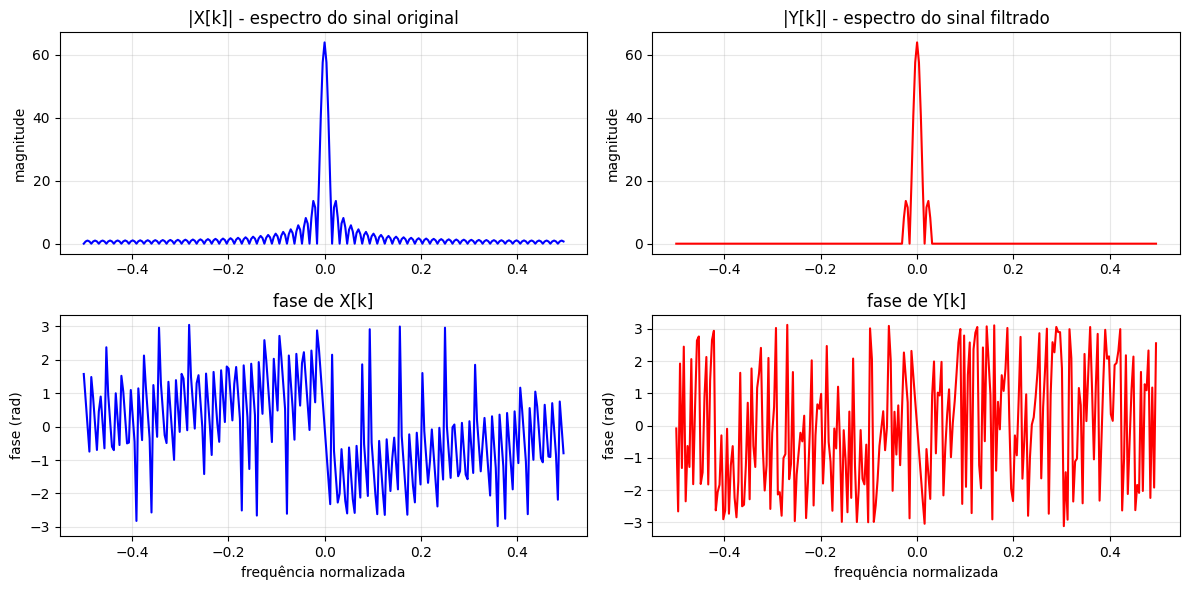

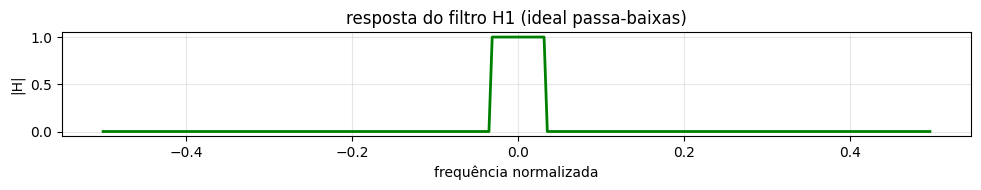

In [ ]:
#Resposta da questão 2b

X2 = dft(x2)
Y2 = dft(y2)

# eixo de frequencia normalizada
f_norm = np.arange(N2) / N2
f_norm[f_norm >= 0.5] -= 1  # centraliza em 0
idx2 = np.argsort(f_norm)
f_norm = f_norm[idx2]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# magnitude de X
axes[0,0].plot(f_norm, np.abs(X2[idx2]), 'b-')
axes[0,0].set_title('|X[k]| - espectro do sinal original')
axes[0,0].set_ylabel('magnitude')
axes[0,0].grid(True, alpha=0.3)

# magnitude de Y
axes[0,1].plot(f_norm, np.abs(Y2[idx2]), 'r-')
axes[0,1].set_title('|Y[k]| - espectro do sinal filtrado')
axes[0,1].set_ylabel('magnitude')
axes[0,1].grid(True, alpha=0.3)

# fase de X
axes[1,0].plot(f_norm, np.angle(X2[idx2]), 'b-')
axes[1,0].set_title('fase de X[k]')
axes[1,0].set_xlabel('frequência normalizada')
axes[1,0].set_ylabel('fase (rad)')
axes[1,0].grid(True, alpha=0.3)

# fase de Y
axes[1,1].plot(f_norm, np.angle(Y2[idx2]), 'r-')
axes[1,1].set_title('fase de Y[k]')
axes[1,1].set_xlabel('frequência normalizada')
axes[1,1].set_ylabel('fase (rad)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# plota a mascara do filtro pra referencia
plt.figure(figsize=(10, 2))
plt.plot(f_norm, H2[idx2], 'g-', linewidth=2)
plt.title('resposta do filtro H1 (ideal passa-baixas)')
plt.xlabel('frequência normalizada')
plt.ylabel('|H|')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Questão 2c (1.0  ponto)

Aplique o filtro $H_1$ no sinal contido no arquivo "noisy_ecg2.mat". Plote o sinal original e o sinal filtrado, bem como seus espectros.


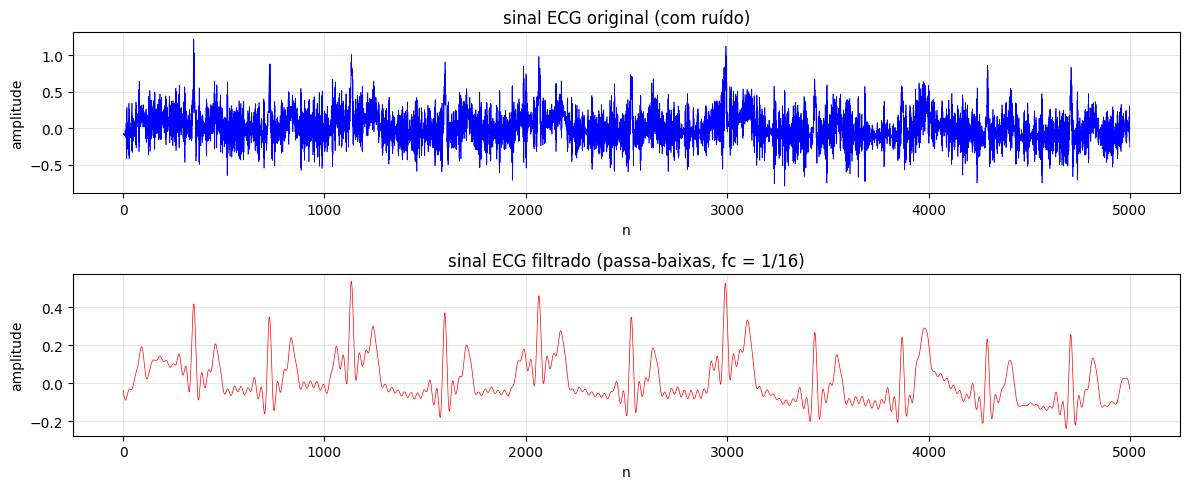

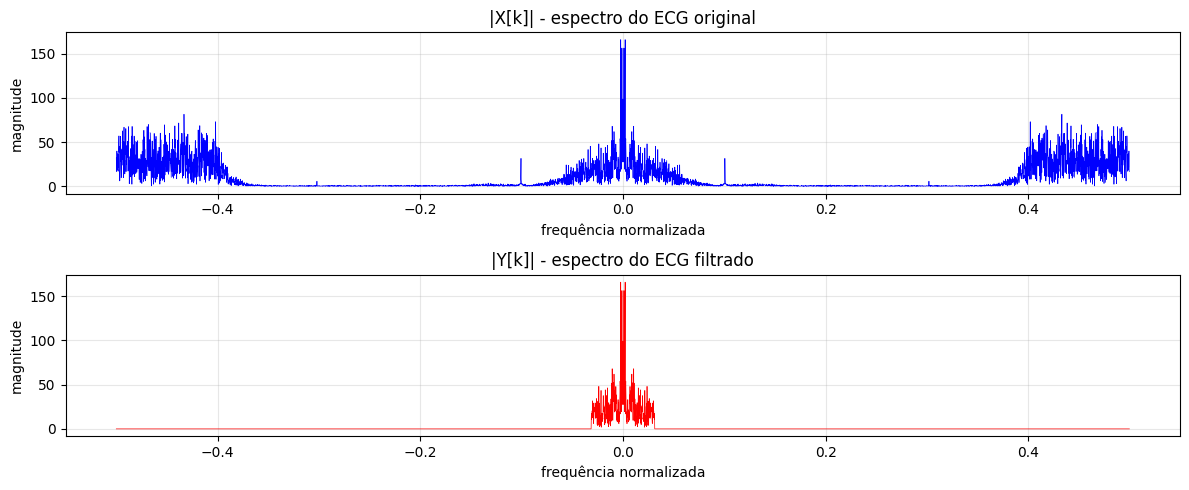

In [ ]:
#Resposta da questão 2c

sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

N_ecg = len(sinal)
n_ecg = np.arange(N_ecg)

# dft do sinal ecg
k_vec = np.arange(N_ecg)
n_vec = np.arange(N_ecg)
# monta a matriz W[k,n]
W = np.exp(-1j * 2 * np.pi * np.outer(k_vec, n_vec) / N_ecg)
X_ecg = W @ sinal  # multiplicacao matricial = dft

# filtro passa-baixas ideal com fc_norm = 1/16
fc_ecg = 1/16
k_corte_ecg = int(fc_ecg * N_ecg / 2)
H_ecg = np.zeros(N_ecg)
H_ecg[0:k_corte_ecg+1] = 1
H_ecg[N_ecg-k_corte_ecg:N_ecg] = 1

# filtragem no dominio da frequencia
Y_ecg = X_ecg * H_ecg

# idft: x = (1/N) * W_inv * X, onde W_inv[n,k] = e^{+j*2*pi*k*n/N}
W_inv = np.exp(1j * 2 * np.pi * np.outer(n_vec, k_vec) / N_ecg)
y_ecg = np.real(W_inv @ Y_ecg) / N_ecg

# --- plots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

ax1.plot(n_ecg, sinal, 'b-', linewidth=0.5)
ax1.set_title('sinal ECG original (com ruído)')
ax1.set_xlabel('n')
ax1.set_ylabel('amplitude')
ax1.grid(True, alpha=0.3)

ax2.plot(n_ecg, y_ecg, 'r-', linewidth=0.5)
ax2.set_title('sinal ECG filtrado (passa-baixas, fc = 1/16)')
ax2.set_xlabel('n')
ax2.set_ylabel('amplitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# espectros
f_ecg = np.arange(N_ecg) / N_ecg
f_ecg[f_ecg >= 0.5] -= 1
idx_ecg = np.argsort(f_ecg)
f_ecg = f_ecg[idx_ecg]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

ax1.plot(f_ecg, np.abs(X_ecg[idx_ecg]), 'b-', linewidth=0.5)
ax1.set_title('|X[k]| - espectro do ECG original')
ax1.set_xlabel('frequência normalizada')
ax1.set_ylabel('magnitude')
ax1.grid(True, alpha=0.3)

ax2.plot(f_ecg, np.abs(Y_ecg[idx_ecg]), 'r-', linewidth=0.5)
ax2.set_title('|Y[k]| - espectro do ECG filtrado')
ax2.set_xlabel('frequência normalizada')
ax2.set_ylabel('magnitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Questão 3 (5.0 pontos)

O teclado de um touch-fone usa sinais de diferentes frequências para especificar quais botões foram pressionados. O teclado tem 12 botões, em um arranjo de quatro linhas e três colunas. Quando um botão é pressionado um sinal é gerado pela soma de dois tons senoidais com frequências diferentes. A frequência mais alta indica a coluna da tecla pressionada, enquanto a menor frequência indica a linha da tecla pressionada. As frequências são geradas de acordo com a tabela:

| | | Coluna | |
| :-: | :-: | :-: | :-: |
| Linha | 1209 Hz | 1336 Hz | 1477 Hz |
| 697 Hz | 1 | 2 | 3 |
| 770 Hz | 4 | 5 | 6 |
| 852 Hz | 7 | 8 | 9 |
| 940 Hz | | 0 | |

A frequência de amostragem é de 8192 Hz, e o som de cada tecla dura um segundo. Escreva um programa que decodifique, de forma automática, um sinal composto por um número de telefone gerado com essas características. Teste o seu programa com os sinais encontrados no arquivo "touch_fone.mat".


SINAL 1 (x)
>>> numero decodificado: 31075580

SINAL 2 (y)
>>> numero decodificado: 911

SINAL 3 (z)
>>> numero decodificado: 2446712


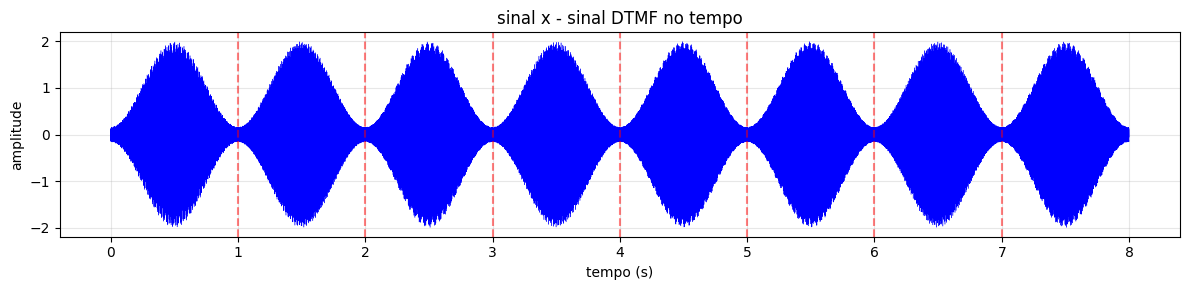

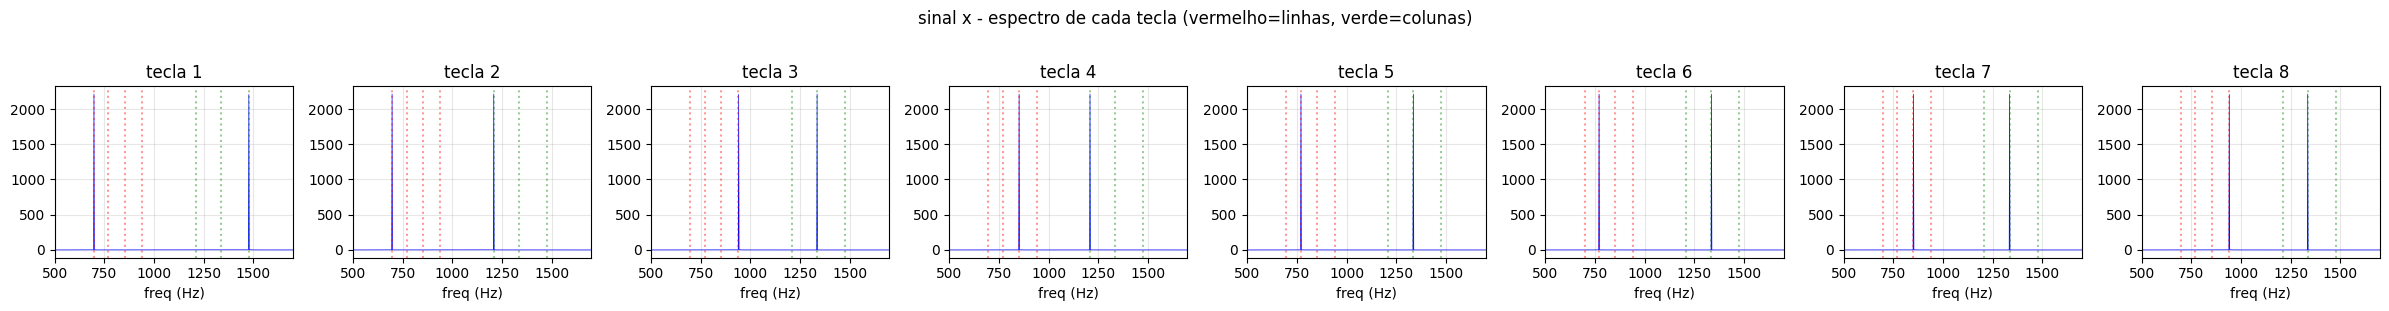

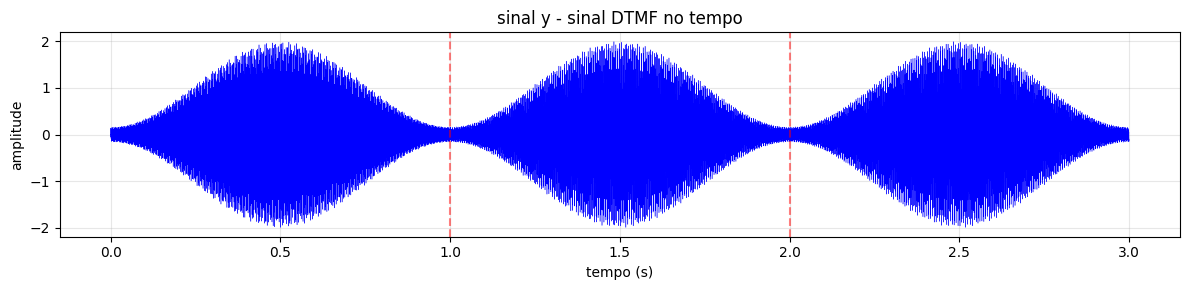

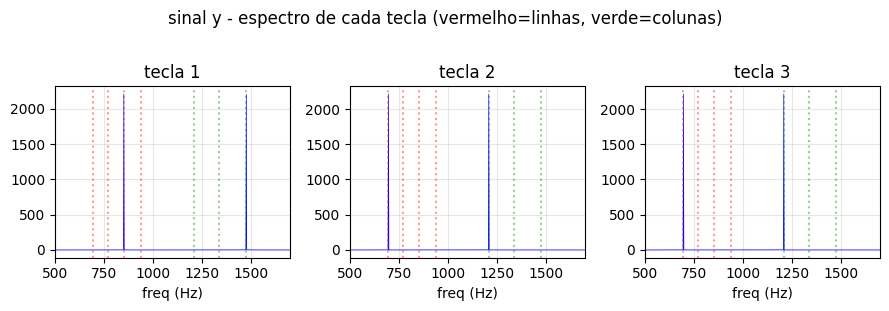

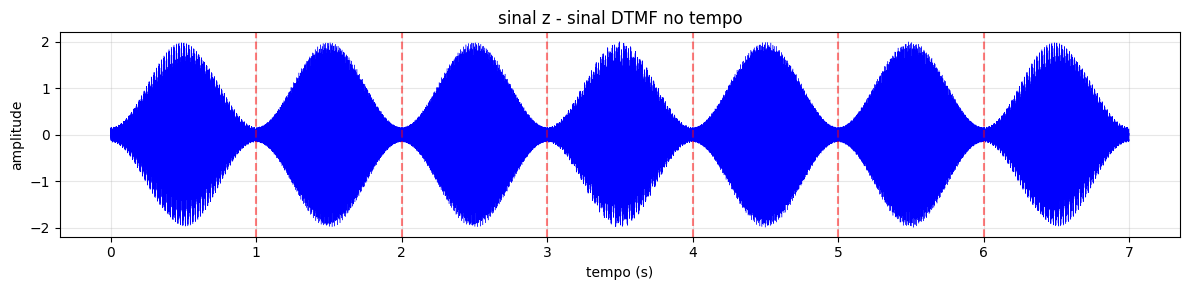

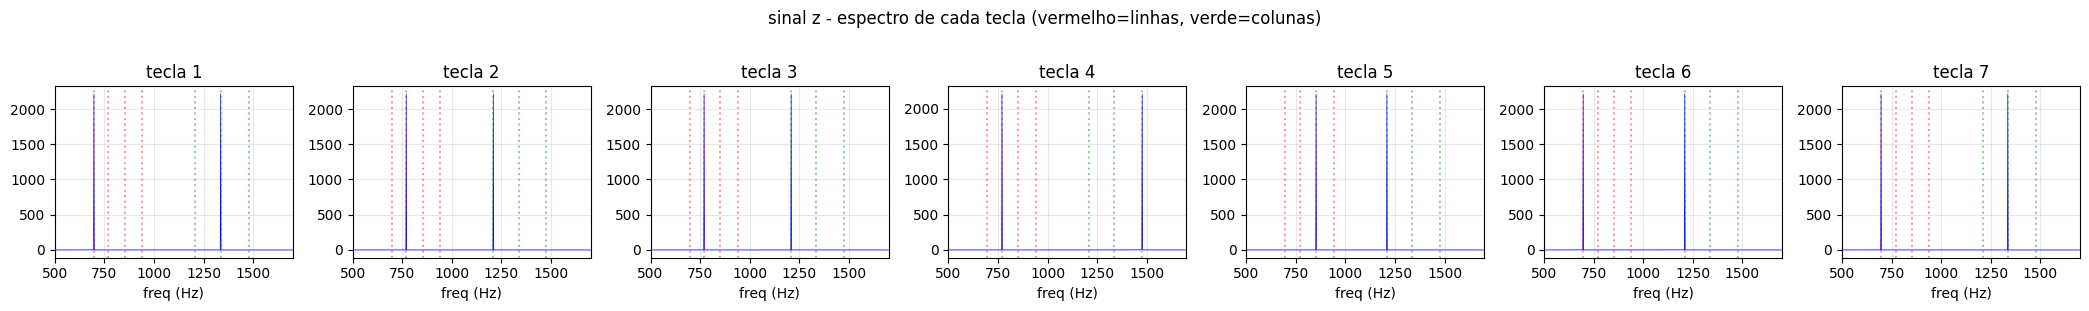

In [ ]:
#Resposta da questão 3

sinal1 = sp.io.loadmat('touch_fone.mat')['x'].ravel()
sinal2 = sp.io.loadmat('touch_fone.mat')['y'].ravel()
sinal3 = sp.io.loadmat('touch_fone.mat')['z'].ravel()

# parametros dtmf
fs_dtmf = 8192 # frequencia de amostragem
duracao = 1
amostras_tecla = fs_dtmf * duracao  # 8192 amostras por tecla

# frequencias das linhas e colunas
freq_linhas = [697, 770, 852, 940]
freq_colunas = [1209, 1336, 1477]

# mapa dtmf: (linha_idx, col_idx) -> digito
teclado = [
    ['1', '2', '3'],
    ['4', '5', '6'],
    ['7', '8', '9'],
    ['*', '0', '#']
]


def detecta_frequencia(segmento, fs, freq_alvo):
    """detecta se uma frequencia especifica esta presente no segmento.
    usa a formula da dft pra calcular o coeficiente apenas no bin desejado,
    ao inves de calcular a dft inteira.
    """
    N = len(segmento)
    k = freq_alvo * N / fs
    n_vec = np.arange(N)
    coef = np.sum(segmento * np.exp(-1j * 2 * np.pi * k * n_vec / N))
    return np.abs(coef)


def decodifica_dtmf(sinal, fs):
    """decodifica um sinal dtmf inteiro, separando por teclas."""
    n_teclas = len(sinal) // amostras_tecla
    numero = ''

    for i in range(n_teclas):
        # pega o segmento de 1 segundo
        inicio = i * amostras_tecla
        fim = inicio + amostras_tecla
        segmento = sinal[inicio:fim]

        # calcula a energia em cada frequencia de linha e coluna
        energias_linhas = []
        for fl in freq_linhas:
            energias_linhas.append(detecta_frequencia(segmento, fs, fl))

        energias_colunas = []
        for fc in freq_colunas:
            energias_colunas.append(detecta_frequencia(segmento, fs, fc))

        # a linha e coluna corretas sao as que tem maior energia
        idx_linha = np.argmax(energias_linhas)
        idx_coluna = np.argmax(energias_colunas)

        digito = teclado[idx_linha][idx_coluna]
        numero += digito

    return numero


# --- decodifica os 3 sinais ---

print('='*50)
print('SINAL 1 (x)')
print('='*50)
num1 = decodifica_dtmf(sinal1, fs_dtmf)
print(f'>>> numero decodificado: {num1}')
print()

print('='*50)
print('SINAL 2 (y)')
print('='*50)
num2 = decodifica_dtmf(sinal2, fs_dtmf)
print(f'>>> numero decodificado: {num2}')
print()

print('='*50)
print('SINAL 3 (z)')
print('='*50)
num3 = decodifica_dtmf(sinal3, fs_dtmf)
print(f'>>> numero decodificado: {num3}')



def plota_dtmf(sinal, nome, fs):
    n_teclas = len(sinal) // amostras_tecla
    t_total = np.arange(len(sinal)) / fs

    plt.figure(figsize=(12, 3))
    plt.plot(t_total, sinal, 'b-', linewidth=0.3)
    plt.title(f'{nome} - sinal DTMF no tempo')
    plt.xlabel('tempo (s)')
    plt.ylabel('amplitude')
    # linhas verticais separando cada tecla
    for i in range(1, n_teclas):
        plt.axvline(x=i*duracao, color='r', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # espectro de cada segmento (1 tecla)
    fig, axes = plt.subplots(1, n_teclas, figsize=(3*n_teclas, 3))
    if n_teclas == 1:
        axes = [axes]

    for i in range(n_teclas):
        seg = sinal[i*amostras_tecla:(i+1)*amostras_tecla]
        N_seg = len(seg)

        freqs_hz = np.arange(N_seg) * fs / N_seg

        # calcula os coeficientes da dft nos bins de interesse
        n_plot = np.arange(N_seg)
        k_plot = np.arange(N_seg // 2)
        W_plot = np.exp(-1j * 2 * np.pi * np.outer(k_plot, n_plot) / N_seg)
        X_seg = W_plot @ seg

        freqs_plot = k_plot * fs / N_seg

        axes[i].plot(freqs_plot, np.abs(X_seg), 'b-', linewidth=0.5)
        axes[i].set_title(f'tecla {i+1}')
        axes[i].set_xlabel('freq (Hz)')
        axes[i].set_xlim([500, 1700])  # faixa dtmf
        # marca as frequencias dtmf
        for fl in freq_linhas:
            axes[i].axvline(x=fl, color='r', linestyle=':', alpha=0.4)
        for fc in freq_colunas:
            axes[i].axvline(x=fc, color='g', linestyle=':', alpha=0.4)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f'{nome} - espectro de cada tecla (vermelho=linhas, verde=colunas)', y=1.02)
    plt.tight_layout()
    plt.show()


plota_dtmf(sinal1, 'sinal x', fs_dtmf)
plota_dtmf(sinal2, 'sinal y', fs_dtmf)
plota_dtmf(sinal3, 'sinal z', fs_dtmf)